# Rossler System

Some demos with Rossler.  Solve with sensitivity, finding equilibrium solutions, computing linearizationabout equilibrium.

## Rossler System and Sensitivity 

Solves the Rossler system and sensitivity together using `Tsit5()`. Three-dimensional phase-space and sensitivity $\sigma$ plots generated with editable standard parameters `a`, `b`, and `c`.

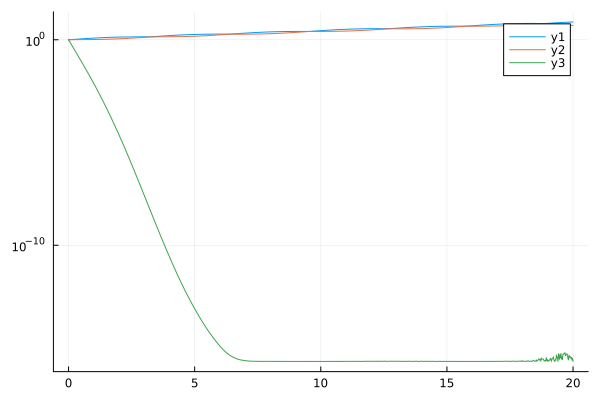

In [154]:
using OrdinaryDiffEq, ComponentArrays, LinearAlgebra, Plots
# Vector field. The state vector is p = [x, y, z].
function f(p, params, t)
    x, y, z = p
    a, b, c = params.a, params.b, params.c
    return [-y - z,
            x + a*y,
            b + z*(x - c)]
end
# Derivative of f with respect to p with identical arguments.
function Df(p, params, t)
    x, y, z = p
    a, c = params.a, params.c
    return [0.0  -1.0  -1.0;
            1.0   a     0.0;
            z     0.0   x-c]
end
# Evolve both fields of the structure.
function rhs!(dU, U, params, t)
    # State equation: p′ = f(p) and Sensitivity equation: J′ = Df(p) * J
    dU.p .= f(U.p, params, t)
    dU.J .= Df(U.p, params, t) * U.J
    return nothing
end
# Actual 
params = (a = 0.2, b = 0.2, c = 5.7)
# Define the structured initial condition:
#   U0.p is a length-3 vector amd U0.J is a 3×3 matrix.
U0 = ComponentArray(
    p = [1.0, 0.0, 0.0],
    J = Matrix{Float64}(I, 3, 3))
# Solve directly for the structured state.
Tmax=20.0;
prob = ODEProblem(rhs!, U0, (0.0, Tmax), params)
sol = solve(prob, Tsit5();
            reltol = 1e-9, abstol = 1e-11, saveat = 0.02)
# Extracting the position data
xyzs=getproperty.(sol.u, :p)
xyzs=stack(xyzs)'
phasePlot = plot(xyzs[:,1],xyzs[:,2],xyzs[:,3])
# Extracting the sensitivity data
Js=getproperty.(sol.u, :J)
sigmas=stack(svdvals.(Js))
svdPlot = plot(sol.t, [sigmas[1,:], sigmas[2,:],sigmas[3,:]])
svdLogPlot = plot(sol.t, [sigmas[1,:], sigmas[2,:],sigmas[3,:].+eps()],yaxis=:log10) 
#Added macine epsilon to avoid zeros in the log plot!

## Rössler Equilibrium points

Define the state vector $\mathbf{p}=(x,y,z)^T$ and the vector field
$$
f(\mathbf{p})=
\begin{pmatrix}
-y-z\\
x+ay\\
b+z(x-c)
\end{pmatrix}.
$$
The Rössler system is then $\dot{\mathbf{p}}=f(\mathbf{p})$. An equilibrium $\mathbf{p}_*$ satisfies
$$
f(\mathbf{p}_*)=\mathbf{0}.
$$
Thus, we solve
$$
-y-z=0,\qquad x+ay=0,\qquad b+z(x-c)=0.
$$

The first two components of $f(\mathbf{p})=\mathbf{0}$ give
$$
y=-z,\qquad x=az.
$$
Substituting into the third component gives
$$
az^2-cz+b=0.
$$

For $a\ne 0$, the roots are
$$
z_\pm=\frac{c\pm\sqrt{c^2-4ab}}{2a}.
$$
Therefore, the equilibrium points are
$$
\boxed{
\mathbf{p}_\pm=
\begin{pmatrix}
az_\pm\\
-z_\pm\\
z_\pm
\end{pmatrix},
\qquad
f(\mathbf{p}_\pm)=\mathbf{0}.
}
$$
 - Two distinct real equilibria when $c^2-4ab>0$.
 - One repeated real equilibrium when $c^2-4ab=0$. 
 - No real equilibria when $c^2-4ab<0$.

For $a=b=0.2$ and $c=5.7$, the two equilibria are approximately
$$
\mathbf{p}_-=
\begin{pmatrix}
0.007026\\
-0.035131\\
0.035131
\end{pmatrix},
\qquad
\mathbf{p}_+=
\begin{pmatrix}
5.692974\\
-28.464869\\
28.464869
\end{pmatrix}.
$$
The first one is the equilibrium visible in the middle of the lower roundabout.  The second one is invisible and well above all our pictures. 

## Linearization of the Rössler system

Let $\mathbf{p}=(x,y,z)^T$ and define
$$
f(\mathbf{p})=
\begin{pmatrix}
-y-z\\
x+ay\\
b+z(x-c)
\end{pmatrix}.
$$
The Rössler system is
$$
\dot{\mathbf{p}}=f(\mathbf{p}).
$$

We use the parameters
$$
a=b=0.2,\qquad c=5.7.
$$

An equilibrium $\mathbf{p}_*$ satisfies $f(\mathbf{p}_*)=\mathbf{0}$.
The two equilibria are
$$
\mathbf{p}_\pm=
\begin{pmatrix}
az_\pm\\
-z_\pm\\
z_\pm
\end{pmatrix},
\qquad
z_\pm=\frac{c\pm\sqrt{c^2-4ab}}{2a}.
$$

We first analyze the lower equilibrium $\mathbf{p}_-$, which has the
smaller $z$ coordinate.

### 1. The Jacobian and the perturbation equation

The Jacobian of $f$ is the matrix of its first partial derivatives:
$$
Df(x,y,z)=
\begin{pmatrix}
\frac{\partial f_1}{\partial x} &
\frac{\partial f_1}{\partial y} &
\frac{\partial f_1}{\partial z}\\
\frac{\partial f_2}{\partial x} &
\frac{\partial f_2}{\partial y} &
\frac{\partial f_2}{\partial z}\\
\frac{\partial f_3}{\partial x} &
\frac{\partial f_3}{\partial y} &
\frac{\partial f_3}{\partial z}
\end{pmatrix}
=
\begin{pmatrix}
0&-1&-1\\
1&a&0\\
z&0&x-c
\end{pmatrix}.
$$

To study motion near an equilibrium, introduce the displacement
$$
\boldsymbol{\eta}
=\mathbf{p}-\mathbf{p}_*
=
\begin{pmatrix}
\xi\\ \upsilon\\ \zeta
\end{pmatrix}.
$$
Since the equilibrium is constant,
$\dot{\boldsymbol{\eta}}=\dot{\mathbf{p}}$. Taylor expansion gives
$$
\dot{\boldsymbol{\eta}}
=f(\mathbf{p}_*+\boldsymbol{\eta})
=f(\mathbf{p}_*)+Df(\mathbf{p}_*)\boldsymbol{\eta}
+\mathcal{O}(\|\boldsymbol{\eta}\|^2).
$$

Using $f(\mathbf{p}_*)=\mathbf{0}$ and writing
$A_*=Df(\mathbf{p}_*)$, we obtain
$$
\boxed{
\dot{\boldsymbol{\eta}}
=A_*\boldsymbol{\eta}
+\mathcal{O}(\|\boldsymbol{\eta}\|^2).
}
$$

For this system, we can identify the remainder exactly. The only
nonlinear term is the product $xz$ in the third equation:
$$
(z_*+\zeta)(x_*+\xi-c)
=z_*(x_*-c)+z_*\xi+(x_*-c)\zeta+\xi\zeta.
$$
Consequently, the exact perturbation equation is
$$
\boxed{
\dot{\boldsymbol{\eta}}
=A_*\boldsymbol{\eta}
+
\begin{pmatrix}
0\\0\\\xi\zeta
\end{pmatrix}.
}
$$

The remainder is quadratic because
$$
|\xi\zeta|
\leq \frac{\xi^2+\zeta^2}{2}
\leq \frac{\|\boldsymbol{\eta}\|_2^2}{2}.
$$
There are no cubic or higher-degree terms in this expansion.

The linearized system is obtained by dropping this quadratic term:
$$
\dot{\boldsymbol{\eta}}_{\mathrm{lin}}
=A_*\boldsymbol{\eta}_{\mathrm{lin}}.
$$
Its solution is
$$
\boldsymbol{\eta}_{\mathrm{lin}}(t)
=e^{A_*t}\boldsymbol{\eta}_{\mathrm{lin}}(0).
$$

### 2. Linearization at the lower equilibrium

The lower equilibrium is approximately
$$
\mathbf{p}_-=
\begin{pmatrix}
0.007026204834\\
-0.035131024171\\
0.035131024171
\end{pmatrix}.
$$

Write the nearby state as
$$
\mathbf{p}=\mathbf{p}_-+\boldsymbol{\eta}_-.
$$

Evaluating the Jacobian at this equilibrium gives
$$
A_-=Df(\mathbf{p}_-)
=
\begin{pmatrix}
0&-1&-1\\
1&a&0\\
z_-&0&az_--c
\end{pmatrix}.
$$

Numerically,
$$
\boxed{
A_-\approx
\begin{pmatrix}
0&-1&-1\\
1&0.2&0\\
0.035131024171&0&-5.692973795166
\end{pmatrix}.
}
$$

Thus, the exact local equations, with coefficients displayed to
rounded precision, are
$$
\begin{aligned}
\dot{\xi}_-&=-\upsilon_- -\zeta_-,\\
\dot{\upsilon}_-&=\xi_-+0.2\upsilon_-,\\
\dot{\zeta}_-&=
0.035131024171\,\xi_-
-5.692973795166\,\zeta_-
+\xi_-\zeta_-.
\end{aligned}
$$

Equivalently, using the exact matrix $A_-$,
$$
\dot{\boldsymbol{\eta}}_-
=A_-\boldsymbol{\eta}_-
+\mathcal{O}(\|\boldsymbol{\eta}_-\|^2).
$$

The eigenvalues of $A_-$ are approximately
$$
\lambda_{-,1}=-5.686975507343,
$$
$$
\lambda_{-,2,3}
=0.097000856088\pm0.995193491030\,i.
$$

For a real eigenvector $\mathbf{v}$ with eigenvalue $\lambda$,
a linearized perturbation in that direction evolves as
$$
\boldsymbol{\eta}(t)=C e^{\lambda t}\mathbf{v}.
$$
The negative real eigenvalue therefore gives a strongly contracting
direction, with decay factor
$$
e^{-5.686975507343t}.
$$

The complex conjugate pair describes motion in a two-dimensional
real invariant plane. If a complex eigenvector is
$\mathbf{v}=\mathbf{r}+i\mathbf{s}$, this plane is spanned by
$\mathbf{r}$ and $\mathbf{s}$.

Within that plane, the positive real part produces exponential
growth with factor
$$
e^{0.097000856088t},
$$
while the imaginary part produces oscillation with angular frequency
approximately $0.995193491030$ radians per unit time.

Thus the lower equilibrium is a **saddle-focus** with:

- a one-dimensional stable eigenspace;
- a two-dimensional unstable spiral plane.

For the nonlinear system, the corresponding local stable and unstable
manifolds are tangent to these spaces at the equilibrium.

### 3. Linearization at the upper equilibrium

The upper equilibrium is approximately
$$
\mathbf{p}_+=
\begin{pmatrix}
5.692973795166\\
-28.464868975829\\
28.464868975829
\end{pmatrix}.
$$

Write
$$
\mathbf{p}=\mathbf{p}_++\boldsymbol{\eta}_+.
$$

The Jacobian at this equilibrium is
$$
A_+=Df(\mathbf{p}_+)
=
\begin{pmatrix}
0&-1&-1\\
1&a&0\\
z_+&0&az_+-c
\end{pmatrix}.
$$

Numerically,
$$
\boxed{
A_+\approx
\begin{pmatrix}
0&-1&-1\\
1&0.2&0\\
28.464868975829&0&-0.007026204834
\end{pmatrix}.
}
$$

The exact local equations, again displaying rounded coefficients, are
$$
\begin{aligned}
\dot{\xi}_+&=-\upsilon_+ -\zeta_+,\\
\dot{\upsilon}_+&=\xi_++0.2\upsilon_+,\\
\dot{\zeta}_+&=
28.464868975829\,\xi_+
-0.007026204834\,\zeta_+
+\xi_+\zeta_+.
\end{aligned}
$$

In Taylor notation,
$$
\dot{\boldsymbol{\eta}}_+
=A_+\boldsymbol{\eta}_+
+\mathcal{O}(\|\boldsymbol{\eta}_+\|^2).
$$

The eigenvalues of $A_+$ are approximately
$$
\lambda_{+,1}=0.192982987308,
$$
$$
\lambda_{+,2,3}
=-0.000004596071
\pm5.428025931107\,i.
$$

The positive real eigenvalue gives an unstable direction with growth
factor
$$
e^{0.192982987308t}.
$$

The complex pair has a small but strictly negative real part.
It therefore defines a stable spiral plane, with decay factor
$$
e^{-0.000004596071t}
$$
and angular frequency approximately $5.428025931107$ radians per
unit time.

The contraction in this plane is extremely weak. Over short time
intervals, the linearized motion can appear almost undamped.
Nevertheless, the real part is negative, so this is a stable plane,
not a center plane.

The upper equilibrium is also a **saddle-focus**, but with:

- a one-dimensional unstable eigenspace;
- a two-dimensional stable spiral plane.

The corresponding nonlinear invariant manifolds are tangent to these
linear spaces at the equilibrium.

### Computations

In [157]:
using LinearAlgebra
params = (a = 0.2, b = 0.2, c = 5.7)
# ------------------------------------------------------------
# Compute the equilibria: solve f(p) = 0
# ------------------------------------------------------------
# The equilibrium equations give y = -z and x = a*z.
# Substitution into the third equation gives a*z² - c*z + b = 0.
a, b, c = params.a, params.b, params.c
D = c^2 - 4*a*b
# For these parameters, the minus sign gives the lower equilibrium.
z_lower = (c - sqrt(D)) / (2*a)
z_upper = (c + sqrt(D)) / (2*a)
p_lower = [a*z_lower, -z_lower, z_lower]
p_upper = [a*z_upper, -z_upper, z_upper]
# ------------------------------------------------------------
# 3. Linearize at each equilibrium
# ------------------------------------------------------------
# For a displacement η = p - p*, the local equation is
# η′ = Df(p*)*η + O(‖η‖²).
# The linearized equation keeps only the term A*η.
A_lower = Df(p_lower, params, 0.0)
A_upper = Df(p_upper, params, 0.0)
# ------------------------------------------------------------
# 4. Compute the eigenvalues and eigenvectors
# ------------------------------------------------------------
E_lower = eigen(A_lower)
E_upper = eigen(A_upper)
# Column k of V is the eigenvector associated with λ[k]:
# A * V[:, k] ≈ λ[k] * V[:, k].
Lambda_lower, V_lower = E_lower.values, E_lower.vectors
Lambda_upper, V_upper = E_upper.values, E_upper.vectors

(ComplexF64[-4.596071039142391e-6 - 5.428025931106868im, -4.596071039142391e-6 + 5.428025931106868im, 0.19298298730797747 + 0.0im], ComplexF64[-0.00024216606306509084 + 0.18720548442781798im -0.00024216606306509084 - 0.18720548442781798im 0.004965076724379894 + 0.0im; -0.03444028383632683 - 0.0013136232602462133im -0.03444028383632683 + 0.0013136232602462133im -0.707576990707828 + 0.0im; -0.9817159411963052 - 0.0im -0.9817159411963052 + 0.0im 0.7066188153693441 + 0.0im])

### 4. Meaning and limitations of the approximation

The notation
$$
f(\mathbf{p}_*+\boldsymbol{\eta})
=A_*\boldsymbol{\eta}
+\mathcal{O}(\|\boldsymbol{\eta}\|^2)
$$
describes the error in the vector field as
$\boldsymbol{\eta}\to\mathbf{0}$.

For the same sufficiently small initial displacement
$\boldsymbol{\eta}_0$, the nonlinear solution satisfies
$$
\mathbf{p}(t)
=\mathbf{p}_*+e^{A_*t}\boldsymbol{\eta}_0
+\mathcal{O}(\|\boldsymbol{\eta}_0\|^2)
$$
uniformly on any fixed finite time interval as
$\boldsymbol{\eta}_0\to\mathbf{0}$. The error constant can depend
on the length of that interval.

This does not imply a uniformly small error for arbitrarily long times.
Unstable components grow, and the quadratic term becomes significant
once the trajectory moves sufficiently far from the equilibrium.

Both equilibria are unstable overall because each has eigenvalues
with positive real part. The stable directions describe special
approaching motions, rather than attraction from a full neighborhood.

### 5. Eigenvalues and directional behavior

A complex conjugate pair corresponds to a real invariant plane,
rather than two separate real eigendirections. The factors below
describe the linearized modes.

| Equilibrium | Eigenvalue(s) | Real invariant space | Linearized behavior |
|---|---|---|---|
| Lower $\mathbf{p}_-$ | $-5.686975507343$ | One-dimensional stable eigendirection | Exponential contraction, with factor $e^{-5.686975507343t}$. |
| Lower $\mathbf{p}_-$ | $0.097000856088\pm0.995193491030\,i$ | Two-dimensional unstable plane | Outward spiraling; growth factor $e^{0.097000856088t}$ and angular frequency $0.995193491030$. |
| Upper $\mathbf{p}_+$ | $0.192982987308$ | One-dimensional unstable eigendirection | Exponential expansion, with factor $e^{0.192982987308t}$. |
| Upper $\mathbf{p}_+$ | $-0.000004596071\pm5.428025931107\,i$ | Two-dimensional stable plane | Very weak inward spiraling; decay factor $e^{-0.000004596071t}$ and angular frequency $5.428025931107$. |